In [ ]:
from math import *
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from one.api import ONE

for parent in [Path.cwd(), *Path.cwd().parents]:
    src_dir = parent / "src"
    if (src_dir / "analyses").exists():
        sys.path.insert(0, str(src_dir))
        break

from analyses.neural_analysis.plot_helpers import encoding_results_to_region_values
from analyses.neural_analysis.brain_slice_custom_colormap import (
    compute_top,
    ctx_slice_RGB,
    get_atlas,
    make_ctx_plot,
    make_sag_plot,
    metadata_regions,
    sag_slice_RGB,
    coord_1,
    coord_2,
    coord_3,
)

one = ONE()


In [36]:
# try to apply for 20 GB memory first
ba = get_atlas()
region_ids_allen = ba.regions.id
region_ids_beryl = ba.regions.remap(region_ids_allen, source_map='Allen', target_map='Beryl')

In [37]:
colors = ["#ffffff","#F8E4AA","#F9D766","#E8AC22","#DA4727"]
cmap1 = LinearSegmentedColormap.from_list("mycmap", colors)

colors = ["#F2EDF7", "#D7C6E7", "#B894D1", "#8E5BB4", "#6B349A"]
cmap1 = LinearSegmentedColormap.from_list("purple_width", colors)

/opt/miniconda3/envs/project3d/lib/python3.10/site-packages/iblatlas/atlas.py:233: RuntimeWarning: invalid value encountered in cast
  ii = np.array(np.round(i)).astype(int)


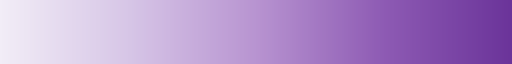

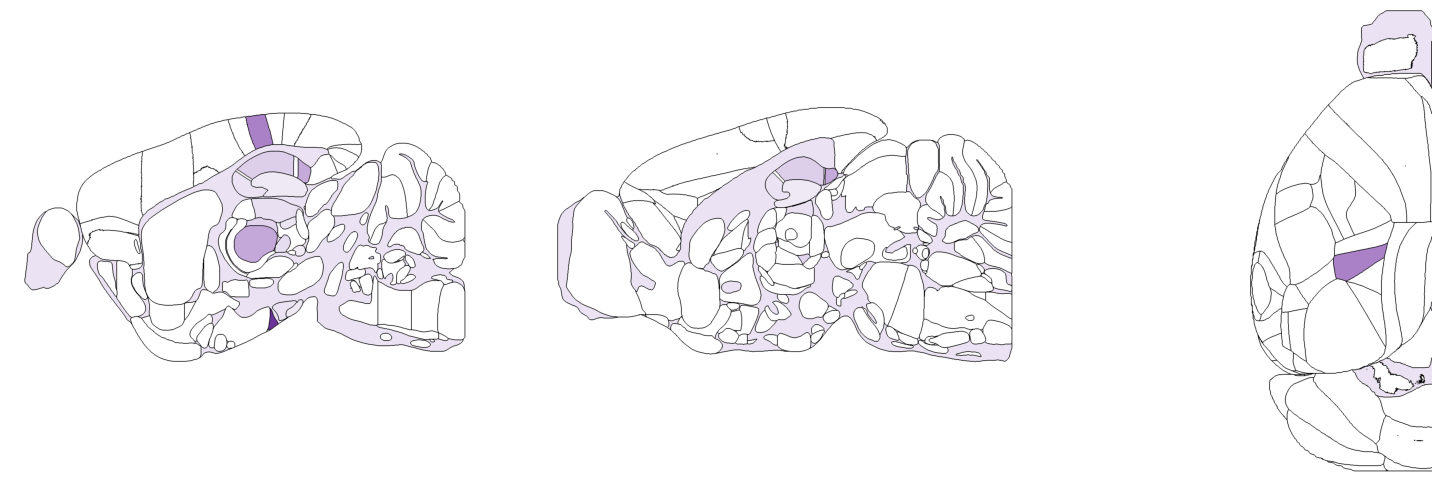

In [ ]:
################ Custom Colormap #############
eid="4b00df29-3769-43be-bb40-128b1cba6d35"
encoding_results_path = f"/Users/dai/Documents/Phd/Research/twoview3d/code/E-RayZer-private.git/E-RayZer-private/plot/figure3/v1/CLS/{eid}/encoding_results.npy"
meta_path = f"/Users/dai/Documents/Phd/Research/twoview3d/code/E-RayZer-private.git/E-RayZer-private/plot/neural_data/{eid}/{eid}_meta.pkl"

# Use this line to visualize which metadata regions are available in the dataset.
# list_region_id, list_region_value = metadata_regions(meta_path)

# Use this line to plot real encoding values.
list_region_id, list_region_value = encoding_results_to_region_values(
    encoding_results_path,
    meta_path,
    eid=eid,
    encoder="cnn",
)

###### inputs #################
# list_region_id: np array of region-id, integers 
# list_region_id: np array of values in associated regions, double float

#### generate sag slices 
im_sag_1=sag_slice_RGB(list_region_id, list_region_value,coord_1,cmap1)
im_sag_2=sag_slice_RGB(list_region_id, list_region_value,coord_2,cmap1)
im_sag_3=sag_slice_RGB(list_region_id, list_region_value,coord_3,cmap1)
# plot sag slices
make_sag_plot(im_sag_1,im_sag_2,im_sag_3)

# plot top view slices
# generate cortex top view slice 
im_ctx_1=ctx_slice_RGB(list_region_id, list_region_value,cmap1)
make_ctx_plot(im_ctx_1)
# plot custom colorbar
cmap1

In [27]:
np.max(list_region_value)

0.3502473584764517

In [28]:
np.min(list_region_value)

0.001447643085197257

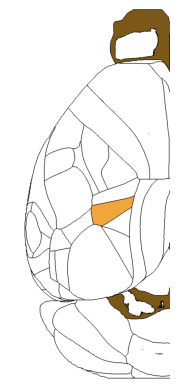

In [29]:
make_ctx_plot(im_ctx_1)

In [ ]:
from analyses.neural_analysis.brain_slice_custom_colormap import sag_slice_RGB_two_encoding_results


(-0.5, 1319.5, 799.5, -0.5)

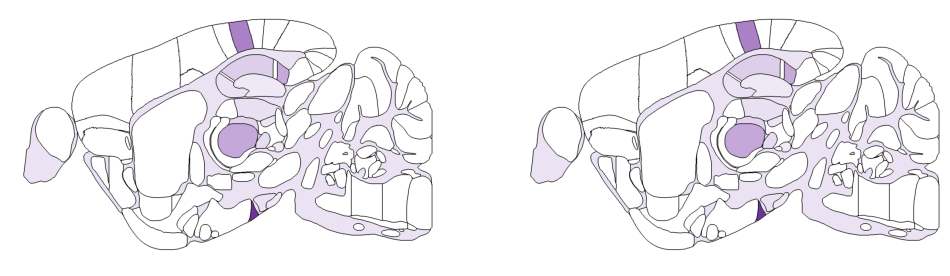

In [ ]:
# TODO: check why two plots look the same
depth_encoding_results_path = f"/Users/dai/Documents/Phd/Research/twoview3d/code/E-RayZer-private.git/E-RayZer-private/plot/figure3/v1/Keypoints/{eid}/encoding_results.npy"
cls_encoding_results_path = f"/Users/dai/Documents/Phd/Research/twoview3d/code/E-RayZer-private.git/E-RayZer-private/plot/figure3/v1/CLS/{eid}/encoding_results.npy"

im_depth, im_cls, value_range = sag_slice_RGB_two_encoding_results(
    depth_encoding_results_path,
    cls_encoding_results_path,
    meta_path,
    coord_1,
    cmap1,
    eid=eid,
)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(im_depth)
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(im_cls)
plt.axis("off")